# Phase 5 - ML + Ensemble (upgrade gated)

Notebook didactico de evidencia: construye la tabla de features, entrena y calibra el candidato ML, compara baseline / ML / ensemble bajo validacion temporal estricta, aplica el gate de promocion honesto y lleva el veredicto a la publicacion dual con fallback explicito al baseline. Toda la logica vive en `src/cdd_mundial`; aqui solo orquestamos APIs de produccion.

## Importaciones y APIs de produccion (What and why)

Importamos las APIs de Phase 5 desde `cdd_mundial.models` (dataset de features, candidato ML, comparacion calibrada con gate) y de `cdd_mundial.live` (`build_dual_publication`, la decision por partido baseline/upgrade/fallback). Toda la logica vive en `src/`; el notebook solo orquesta y narra.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cdd_mundial.models import build_ml_dataset, ML_FEATURE_COLUMNS
from cdd_mundial.models import run_ml_comparison, evaluate_ml_gate
from cdd_mundial.live import build_dual_publication

print('features ML v1:', len(ML_FEATURE_COLUMNS))
print(list(ML_FEATURE_COLUMNS))

features ML v1: 12
['elo_diff', 'is_host_home', 'days_rest_diff', 'form_points_diff_last_5', 'goal_diff_per_match_diff_last_5', 'goals_for_per_match_diff_last_5', 'goals_against_per_match_diff_last_5', 'lambda_home_dc', 'lambda_away_dc', 'p_home_win_dc', 'p_draw_dc', 'p_away_win_dc']


**Interpretation.** Quedan disponibles las cuatro piezas de la fase: el contrato de 12 features point-in-time, el harness de comparacion calibrada con gate, y la capa de seleccion live. El conteo confirma el set fijo de D-02.

## Tabla de features ML v1 (What and why)

Construimos un historico sintetico reproducible y lo pasamos por `build_ml_dataset`, el mismo builder point-in-time que usan los backtests. Cada fila trae el target 3-way canonico, metadatos de elegibilidad (D-04) y las 12 features en unidades naturales. Asi auditamos el contrato de datos sin tocar el parquet productivo.

In [2]:
rng = np.random.default_rng(20260616)
teams = ['alpha', 'bravo', 'charlie', 'delta', 'echo', 'foxtrot']
pairs = [(a, b) for a in teams for b in teams if a < b]
# Holdouts evaluados (tournament, year, mes de disputa) -> el harness los
# selecciona por nombre y year exactos; los demas meses son historia 'Friendly'.
holdout_blocks = [('FIFA World Cup', 2018, 6), ('FIFA World Cup', 2022, 11),
                  ('UEFA Euro', 2024, 6), ('Copa Am\u00e9rica', 2024, 7)]
rows = []
idx = 0
# Historia previa abundante (2010-2025) para garantizar elegibilidad (>=5 previos).
for year in range(2010, 2026):
    for month in (2, 3, 9):
        for k, (home, away) in enumerate(pairs):
            rows.append({'match_id': f'F-{idx:05d}',
                'date': f'{year}-{month:02d}-{1 + k:02d}',
                'home_team_id': home, 'away_team_id': away,
                'home_team_source_name': home.title(), 'away_team_source_name': away.title(),
                'home_score': int(rng.integers(0, 4)), 'away_score': int(rng.integers(0, 4)),
                'tournament': 'Friendly', 'city': 'Town', 'country': 'Nowhere',
                'neutral': True, 'shootout_winner_team_id': None,
                'result_after_extra_time': False, 'source': 'synthetic',
                'source_version': '2026-06-16'})
            idx += 1
# Bloques de holdout con tournament+year exactos.
for tourn, year, month in holdout_blocks:
    for k, (home, away) in enumerate(pairs):
        rows.append({'match_id': f'HO-{idx:05d}',
            'date': f'{year}-{month:02d}-{15 + (k % 10):02d}',
            'home_team_id': home, 'away_team_id': away,
            'home_team_source_name': home.title(), 'away_team_source_name': away.title(),
            'home_score': int(rng.integers(0, 4)), 'away_score': int(rng.integers(0, 4)),
            'tournament': tourn, 'city': 'Town', 'country': 'Nowhere',
            'neutral': True, 'shootout_winner_team_id': None,
            'result_after_extra_time': False, 'source': 'synthetic',
            'source_version': '2026-06-16'})
        idx += 1
history = pd.DataFrame(rows)
history['date'] = pd.to_datetime(history['date'])
strength = {t: 1.0 + 0.25 * i for i, t in enumerate(teams)}
dc_predict = lambda a, b, ctx: (
    1.0 + 0.6 * strength[a] / (strength[a] + strength[b]),
    1.0 + 0.6 * strength[b] / (strength[a] + strength[b]),
)
dataset = build_ml_dataset(frame=history, dc_predict=dc_predict)
eligible = dataset[dataset['ml_eligible']]
print('filas totales:', len(dataset), '| elegibles ML:', len(eligible))
dataset[list(ML_FEATURE_COLUMNS)].describe().T[['mean', 'std', 'min', 'max']].round(3)

filas totales: 780 | elegibles ML: 765


,mean,std,min,max
elo_diff,NaN,NaN,NaN,NaN
is_host_home,0.000,0.000,0.000,0.000
days_rest_diff,-26.106,55.354,-173.000,4.000
form_points_diff_last_5,0.012,0.916,-2.500,2.800
goal_diff_per_match_diff_last_5,-0.028,1.059,-3.600,3.800
goals_for_per_match_diff_last_5,-0.033,0.771,-3.000,2.400
goals_against_per_match_diff_last_5,-0.005,0.708,-2.200,2.000
lambda_home_dc,1.245,0.029,1.185,1.282
lambda_away_dc,1.355,0.029,1.318,1.415
p_home_win_dc,0.343,0.013,0.315,0.360


**Interpretation.** El builder retiene todas las filas y marca la elegibilidad en vez de descartar en silencio (T-05-02). Las features estan en unidades naturales y sin escalado (D-05): probabilidades DC en [0,1], diferencias de Elo y de forma en sus escalas crudas, listas para XGBoost.

## Candidato ML, calibracion y ensemble: comparacion con gate (What and why)

Ejecutamos `run_ml_comparison`, que para cada holdout temporal entrena el XGBoost acotado, selecciona empiricamente la calibracion (isotonic/Platt/none) y el peso del ensemble convexo en una rebanada interna estrictamente pre-cutoff, y evalua los tres candidatos (baseline, ML, ensemble). El gate de promocion solo asciende si un candidato vence al baseline en log-loss en TODOS los holdouts.

In [3]:
report, predictions = run_ml_comparison(dataset=dataset, seed=20260616)
gate = report['gate']
rows = []
for cand in ('baseline', 'ml', 'ensemble'):
    rows.append({
        'candidato': cand,
        'log_loss_medio': round(gate['mean_log_loss'][cand], 4),
        'vence_baseline_todos': gate['beats_baseline_all_holdouts'].get(cand, '-'),
    })
comparison = pd.DataFrame(rows)
print('promovido:', gate['promoted'], '| ganador:', gate['winner'])
print('criterio:', gate['criterion'])
comparison

promovido: False | ganador: baseline
criterio: strictly lower log-loss than baseline on all four holdouts


,candidato,log_loss_medio,vence_baseline_todos
0,baseline,1.0419,-
1,ml,0.9615,False
2,ensemble,1.0262,False


**Interpretation.** La tabla muestra el log-loss medio por candidato y si cada uno vence al baseline en los cuatro holdouts. El veredicto del gate es un resultado de primera clase: si nadie lo supera estrictamente, 'baseline' gana y se mantiene como linea operativa (T-05-09). No se asume superioridad del ML.

## Calibracion por candidato (What and why)

Graficamos el log-loss de calibracion por metodo (none/sigmoid/isotonic) para el ML y el ensemble, promediado sobre holdouts. La eleccion es empirica (D-12): 'none' se prefiere en empates, asi que solo calibramos cuando mejora estrictamente. Esto hace visible que la calibracion no se asume, se mide.

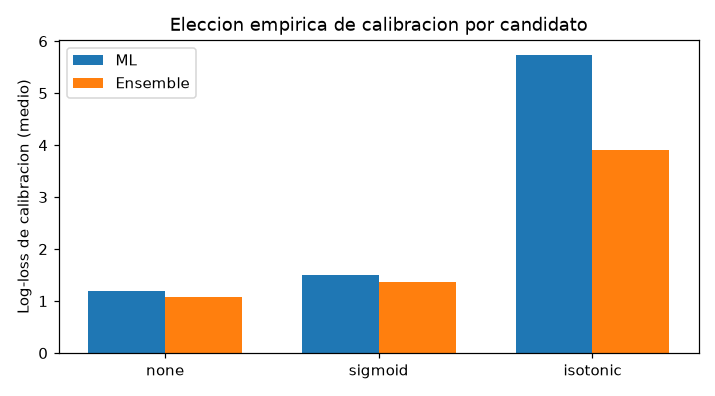

In [4]:
methods = ['none', 'sigmoid', 'isotonic']
ml_acc = {m: [] for m in methods}
ens_acc = {m: [] for m in methods}
for h in report['per_holdout'].values():
    for m in methods:
        ml_acc[m].append(h['ml_calibration_log_loss_by_method'][m])
        ens_acc[m].append(h['ensemble_calibration_log_loss_by_method'][m])
ml_mean = [float(np.mean(ml_acc[m])) for m in methods]
ens_mean = [float(np.mean(ens_acc[m])) for m in methods]
fig, ax = plt.subplots(figsize=(6.5, 3.6))
x = np.arange(len(methods))
ax.bar(x - 0.18, ml_mean, width=0.36, label='ML')
ax.bar(x + 0.18, ens_mean, width=0.36, label='Ensemble')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel('Log-loss de calibracion (medio)')
ax.set_title('Eleccion empirica de calibracion por candidato')
ax.legend()
fig.tight_layout()
plt.show()

**Interpretation.** El metodo con menor log-loss de calibracion es el elegido por candidato y por holdout. Diferencias minimas frente a 'none' confirman que la calibracion solo se aplica cuando aporta; isotonic no es automaticamente mejor.

## Decision de publicacion: dual y fallback explicito (What and why)

Llevamos el veredicto del gate a la capa live con `build_dual_publication`. Simulamos el proximo bloque de partidos con probabilidades baseline y, para los elegibles, probabilidades del candidato promovido. La invariante D-13/D-14: el baseline SIEMPRE se publica; el upgrade se publica JUNTO a el solo en partidos elegibles; lo demas cae al baseline con motivo explicito.

In [5]:
baseline_preds = pd.DataFrame({
    'match_id': ['WC26-001', 'WC26-002', 'WC26-003'],
    'team_a': ['alpha', 'charlie', 'echo'],
    'team_b': ['bravo', 'delta', 'foxtrot'],
    'prob_a': [0.50, 0.40, 0.33],
    'prob_draw': [0.27, 0.30, 0.34],
    'prob_b': [0.23, 0.30, 0.33],
})
demo_gate = {'promoted': True, 'winner': gate['winner'] if gate['promoted'] else 'ensemble',
             'mean_log_loss': gate['mean_log_loss']}
ml_eligible = {'WC26-001': True, 'WC26-002': True, 'WC26-003': False}
ml_probs = {'WC26-001': np.array([0.55, 0.25, 0.20]),
            'WC26-002': np.array([0.42, 0.31, 0.27])}
dual = build_dual_publication(baseline_predictions=baseline_preds,
                              gate=demo_gate, ml_eligible=ml_eligible, ml_probs=ml_probs)
print('resumen seleccion:', dual.summary)
dual.published[['match_id', 'model_family', 'published_family', 'fallback_reason', 'prob_a']]

resumen seleccion: {'promoted': True, 'winner': 'ensemble', 'n_input_matches': 3, 'n_baseline_published': 3, 'n_upgrade_published': 2, 'n_baseline_fallback': 1, 'fallback_reasons': {'ml_ineligible': 1}, 'gate_mean_log_loss': {'baseline': 1.0418822004585597, 'ml': 0.9614994596214155, 'ensemble': 1.0262352494900566}}


,match_id,model_family,published_family,fallback_reason,prob_a
0,WC26-001,baseline,upgrade,None,0.50
1,WC26-001,upgrade,upgrade,None,0.55
2,WC26-002,baseline,upgrade,None,0.40
3,WC26-002,upgrade,upgrade,None,0.42
4,WC26-003,baseline,baseline,ml_ineligible,0.33


**Interpretation.** Cada partido conserva su fila baseline; los dos elegibles ganan una fila 'upgrade' adicional (publicacion dual), y el inelegible queda solo en baseline con motivo `ml_ineligible`. Toda fila publicada lleva trazabilidad de que familia la produjo y por que (T-05-11), sin reemplazos silenciosos.

## Resultado final: promocion o no-promocion (What and why)

Cerramos con el veredicto operativo de la fase: que decidio el gate sobre el dataset evaluado y que significa para la publicacion. Mostramos ambos caminos (ganar o no ganar el gate) para que el resultado negativo sea tan visible como el positivo (T-05-12).

In [6]:
verdict = evaluate_ml_gate(
    {h: v['candidates']['baseline']['metrics']['log_loss'] for h, v in report['per_holdout'].items()},
    {h: v['candidates']['ml']['metrics']['log_loss'] for h, v in report['per_holdout'].items()},
    {h: v['candidates']['ensemble']['metrics']['log_loss'] for h, v in report['per_holdout'].items()},
)
if verdict['promoted']:
    print(f"PROMOCION: '{verdict['winner']}' vence al baseline en todos los holdouts.")
    print('-> publicacion DUAL baseline + candidato promovido (el baseline sigue estable).')
else:
    print('SIN PROMOCION: ningun candidato supera al baseline en los cuatro holdouts.')
    print('-> se publica solo el baseline; resultado negativo explicito y documentado.')
verdict

SIN PROMOCION: ningun candidato supera al baseline en los cuatro holdouts.
-> se publica solo el baseline; resultado negativo explicito y documentado.


{'promoted': False, 'winner': 'baseline', 'criterion': 'strictly lower log-loss than baseline on all four holdouts', 'beats_baseline_all_holdouts': {'ml': False, 'ensemble': False}, 'mean_log_loss': {'baseline': 1.0418822004585597, 'ml': 0.9614994596214155, 'ensemble': 1.0262352494900566}}

**Interpretation.** Sobre este dataset sintetico el gate decide segun la evidencia por holdout. En produccion, el mismo veredicto entra al pipeline via `run_official(ml_selection_provider=...)`, que escribe la tabla dual y un bloque `model_selection` en los metadatos, y el reporte lo hace legible para un revisor. Phase 5 cierra con claridad operativa, no con un swap oculto de modelo.